# Entendendo os dados

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Tipos de dados

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- Numéricos: int64, float64
- Categóricos: str

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Shape

In [4]:
df.shape

(7043, 21)

- Número de linhas: 7043
- Número de colunas: 21

### Valores nulos

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

- Sem valores nulos no dataset

### Distribuição do churn

In [6]:
churn_dist = df['Churn'].value_counts(normalize=True)
churn_dist

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

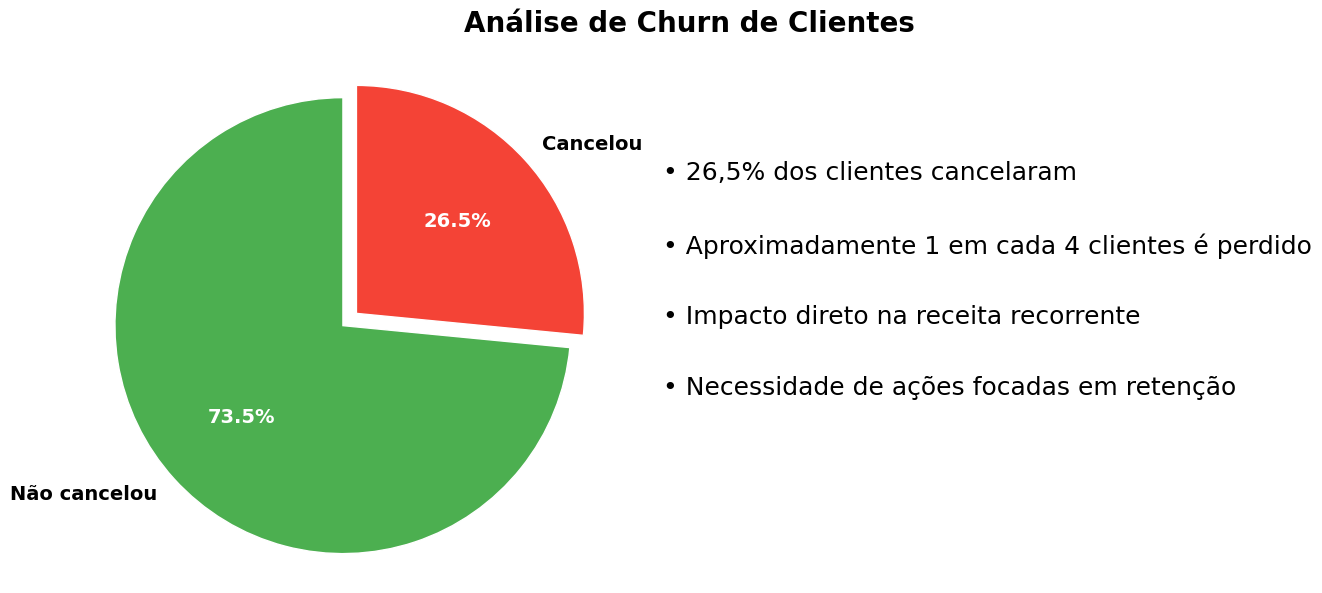

In [26]:
import matplotlib.pyplot as plt

labels = ['Não cancelou', 'Cancelou']
sizes = churn_dist.values
explode=[0, 0.08]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={'width_ratios': [1, 1.2]}
)

# ===== GRÁFICO (ESQUERDA) =====
wedges, texts, autotexts = ax1.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 11},
    colors=['#4CAF50', '#F44336']
)

for text in texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')
    text.set_color('black')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

ax1.axis('equal')

# ===== TEXTO (DIREITA) =====
ax2.axis('off')

texto = (
    "• 26,5% dos clientes cancelaram\n\n"
    "• Aproximadamente 1 em cada 4 clientes é perdido\n\n"
    "• Impacto direto na receita recorrente\n\n"
    "• Necessidade de ações focadas em retenção"
)

ax2.text(
    0,
    0.8,
    texto,
    fontsize=18,
    va='top',
    wrap=True,
    linespacing=1.6 
)

fig.suptitle(
    "Análise de Churn de Clientes",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

A taxa de churn de 26,5% indica que aproximadamente 1 em cada 4 clientes está sendo perdido.
Considerando o custo elevado de aquisição de novos clientes, essa taxa representa um impacto direto na receita recorrente e na sustentabilidade do negócio.

Embora a base atual ainda seja majoritariamente composta por clientes ativos (73,5%), o volume de cancelamentos sugere a necessidade de ações focadas em retenção.

Esse cenário reforça a importância de análises aprofundadas para identificar os principais drivers de churn, permitindo a implementação de estratégias como melhoria na experiência do cliente, personalização de ofertas e ações proativas de retenção.